In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from empiricaldist import Pmf, Cdf
from scipy.stats import chi2_contingency

# Pandas es una herramienta de manipulación de datos general. empiricaldist es una herramienta de probabilidad.

In [7]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
df = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
display(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [83]:
# custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
# sns.set_palette(custom_colors)

custom_palette_species = {
    'Adelie': '#1f77b4',  # azul
    'Chinstrap': '#ff7f0e',  # naranja
    'Gentoo': '#2ca02c'  # verde
}

# 📊 Estableciendo relaciones: gráficos de violín y boxplots
Los **boxplots** y **violin plots** son herramientas clave en el análisis exploratorio de datos (EDA) cuando se busca **comparar distribuciones entre grupos**, por ejemplo:
* Nutrientes por cultivo
* Variables por región
* Indicadores según tratamiento o condición
Ambos gráficos permiten ir más allá del promedio y entender **cómo se distribuyen realmente los datos**.

## 🔍 Diferencia entre boxplot y violin plot

* El **boxplot** resume la distribución mediante estadísticos clave (mediana, cuartiles, rango).

* El **violin plot** muestra además la **forma completa de la distribución**, incluyendo su densidad.

En otras palabras:
* **Boxplot → resumen estadístico**
* **Violin plot → forma + distribución**

## 📦 2. Boxplot
El boxplot es una representación compacta que permite identificar rápidamente:
* Tendencia central
* Dispersión
* Valores atípicos

### 📌 Componentes
* **Mediana (Q2):** valor central de los datos
* **Cuartiles (Q1 y Q3):** dividen los datos en cuatro partes
* **Rango intercuartílico (IQR):** Q3 - Q1
* **Bigotes (whiskers):** extensión de los datos sin outliers
* **Outliers:** valores atípicos fuera del rango esperado

### 🧠 ¿Cuándo usarlo?
* Comparar distribuciones entre múltiples grupos
* Detectar **asimetría** en los datos
* Identificar **valores extremos o anomalías**
* Cuando se necesita una visualización **simple y clara**
Ejemplo:
Comparar niveles de **Nitrógeno (N)** entre diferentes cultivos.

## 🎻 3. Violin plot
El violin plot combina:
* Un **boxplot interno**
* Una **curva de densidad (KDE)** a ambos lados
Esto permite visualizar **cómo se distribuyen los datos dentro de cada grupo**.

### 📌 Características
* Muestra la **densidad de probabilidad**
* Permite identificar **múltiples picos (multimodalidad)**
* Revela **concentraciones de datos** que el boxplot no muestra

### 🚀 Ventajas sobre el boxplot
* Mayor detalle sobre la distribución
* Permite ver si los datos están:
  * concentrados
  * dispersos
  * agrupados en varios rangos

## 🎯 Conclusión rápida
* Usa **boxplot** para una visión rápida y comparativa
* Usa **violin plot** cuando quieras entender la **forma real de la distribución**



## 4. Ejemplos con penguins dataset
- Boxplot: `bill_length_mm` por especie
- Violin plot: misma variable
- Comparación lado a lado

## 5. Interpretación y conclusiones

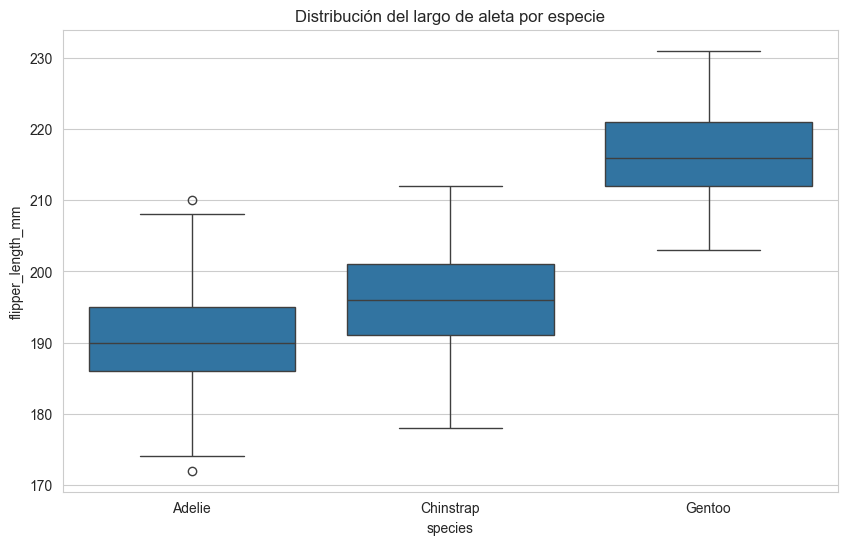

In [ ]:
# Configurar estilo
sns.set_style("whitegrid")

# Boxplot básico
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='flipper_length_mm')
plt.title('Distribución del largo de aleta por especie')
plt.show()

# ¿Qué especie tiene las aletas más largas en promedio? (Gentoo)
# ¿Hay diferencias significativas entre especies? (Sí, claramente separadas)
# ¿Hay valores atípicos (outliers)? (Los puntos fuera de los bigotes)
# ¿Cuál especie tiene mayor variabilidad? (Mirando la altura de las cajas)


C:\Users\alvar\AppData\Local\Temp\ipykernel_33324\998259262.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


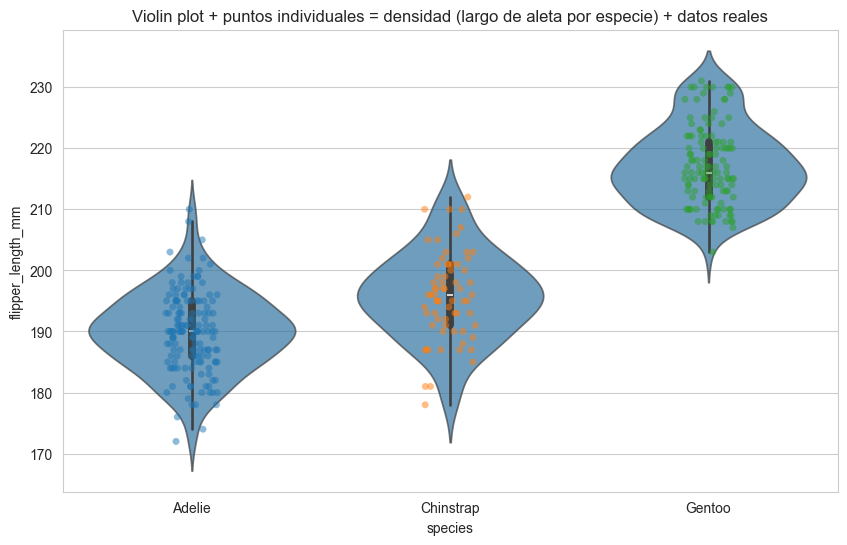

In [84]:
### Violin plot (más informativo) ###
## Combinar Violinplot + Stripplot ##

plt.figure(figsize=(10, 6))

# Violinplot (la estructura)
sns.violinplot(
    data=df, 
    x='species', 
    y='flipper_length_mm',
    # inner=None,  # ← quita el boxplot interno para no saturar
    alpha=0.7
)



# Stripplot (los puntos individuales)
sns.stripplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    color='blue',  # ← color que contraste
    alpha=0.5,      
    jitter=True,     # ← separa puntos horizontalmente(aleatorio) para mostrar densidad
    palette= custom_palette_species
)

plt.title('Violin plot + puntos individuales = densidad (largo de aleta por especie) + datos reales')
plt.show()

# Forma de la distribución: ¿es bimodal? ¿simétrica? ¿sesgada?
# Densidad: las partes más anchas = más concentración de datos

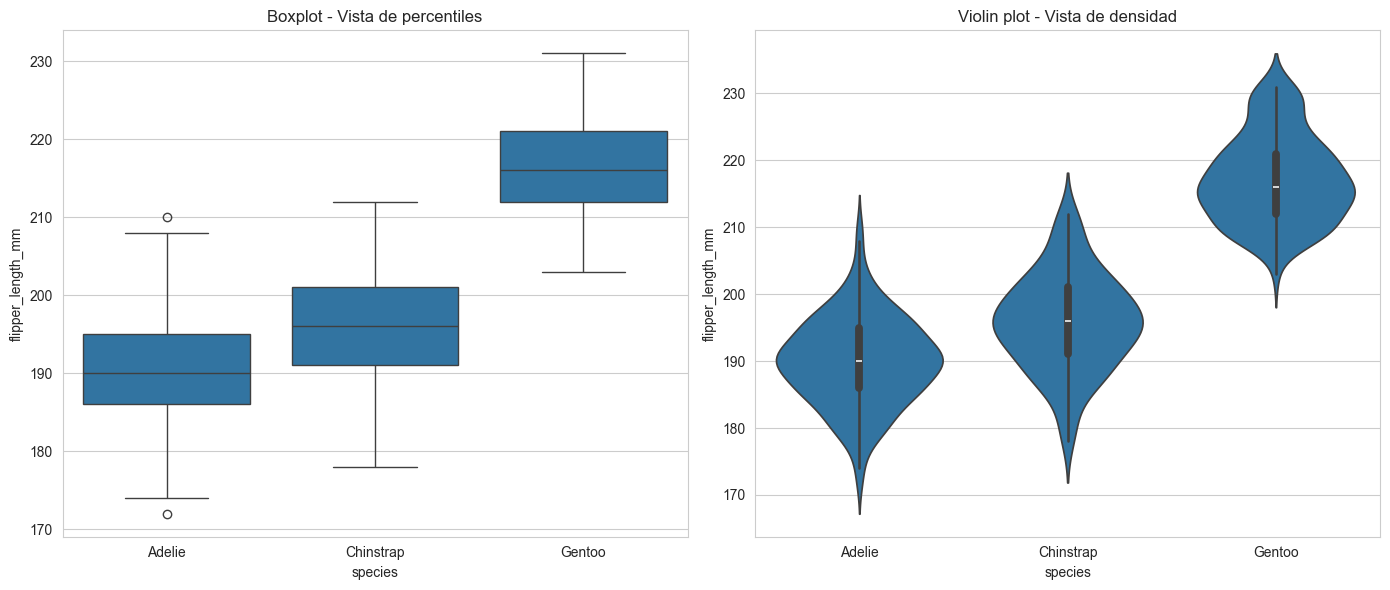

In [ ]:
# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
# Boxplot
sns.boxplot(data=df, x='species', y='flipper_length_mm', ax=ax1)
ax1.set_title('Boxplot - Vista de percentiles')
# Violin plot
sns.violinplot(data=df, x='species', y='flipper_length_mm', ax=ax2)
ax2.set_title('Violin plot - Vista de densidad')
plt.tight_layout()
plt.show()

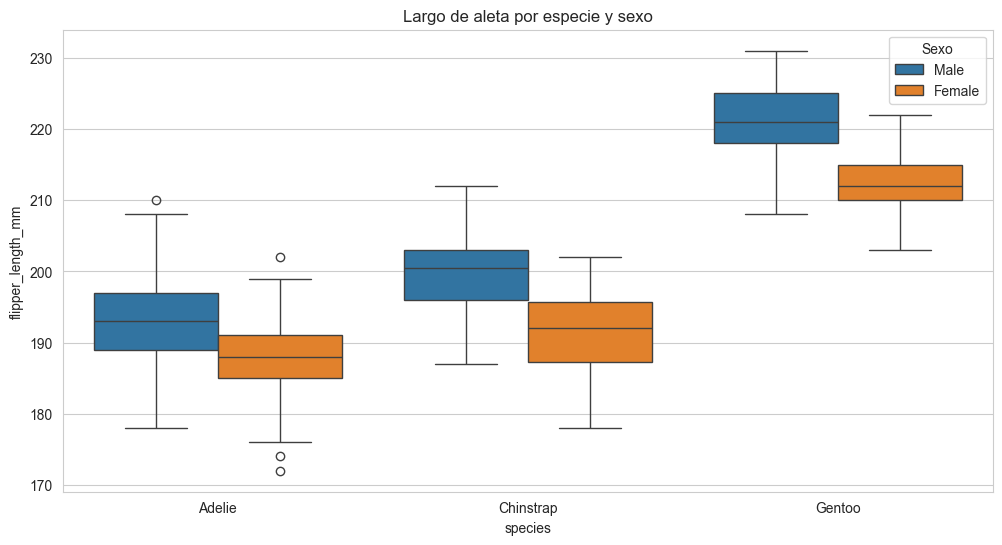

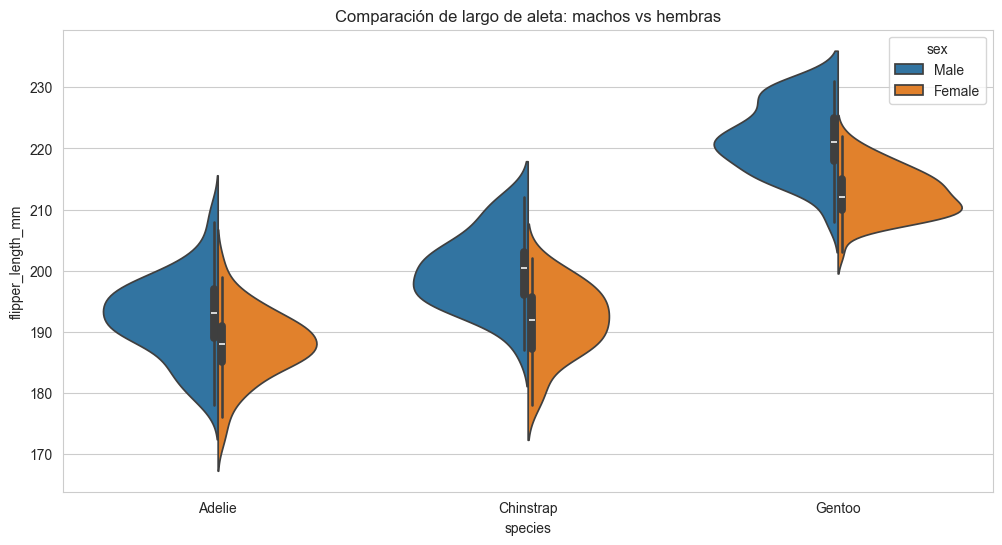

In [ ]:
### Análisis más completo con color por sexo ###

# Boxplot diferenciando por sexo
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='species', y='flipper_length_mm', hue='sex')
plt.title('Largo de aleta por especie y sexo')
plt.legend(title='Sexo')
plt.show()
# Violin plot con split (mitad-mitad para comparar sexos)
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='species', y='flipper_length_mm', hue='sex', split=True)
plt.title('Comparación de largo de aleta: machos vs hembras')
plt.show()

# ¿Las tres especies tienen distribuciones similares? (No: Gentoo tiene aletas claramente más largas)
# ¿Existe dimorfismo sexual en el largo de aleta? (Sí: los machos suelen tener aletas más largas en todas las especies)
# ¿La distribución es normal o tiene sesgo? (El violin plot te lo muestra visualmente)
# ¿Hay superposición entre especies? (Adelie y Chinstrap se superponen algo; Gentoo está separada)

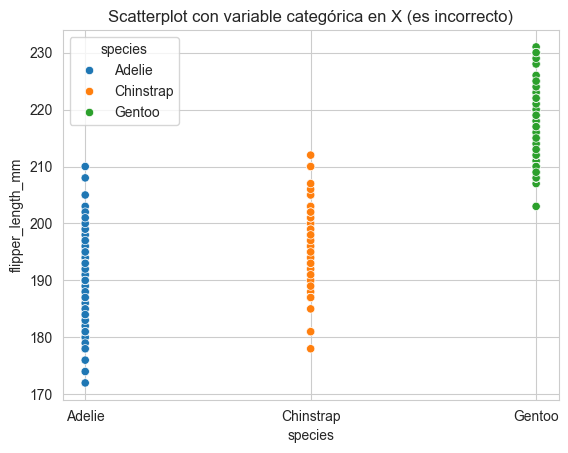

In [63]:
### El uso de Scatterplot con categórica en X (INCORRECTO) ##

# Un scatterplot está diseñado para mostrar la relación entre DOS variables numéricas:

sns.scatterplot(
    data=df,
    x='species',          # categórico
    y='flipper_length_mm', #(variable cuantitativa continua)
    hue='species'           # categórico (opcional para color por especie
)
plt.title('Scatterplot con variable categórica en X (es incorrecto)')
plt.show()

#  Resultado: puntos amontonados en 3 columnas, sin estructura clara

# Problemas con este gráfico:
# Overplotting: Los puntos se amontonan unos encima de otros
# No muestra la distribución: No se ve la mediana, cuartiles, ni densidad
# Difícil de comparar: Solo ves puntos sueltos sin estructura

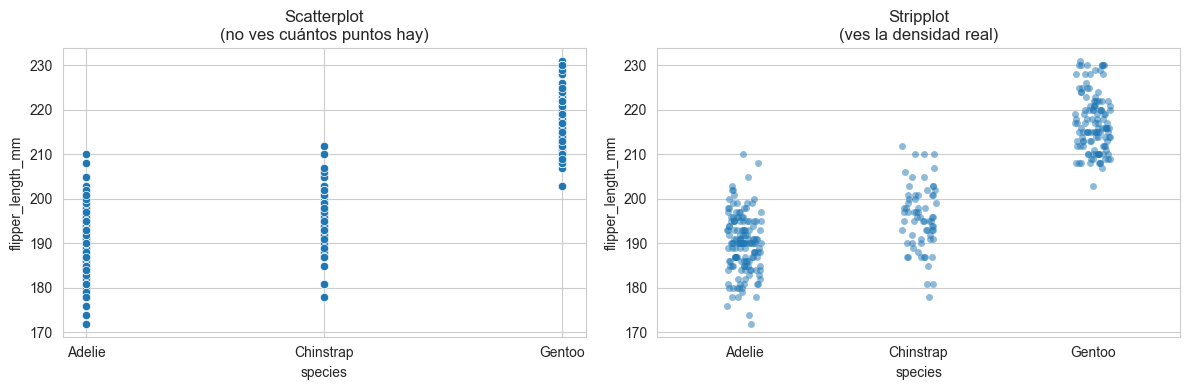

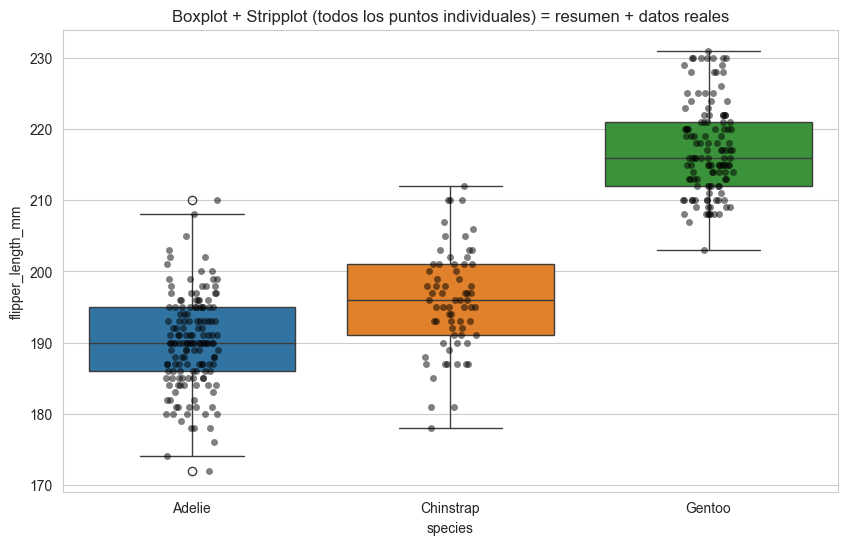

In [86]:
### STRIPPLOT (con jitter) ### 
# Stripplot → mejora sobre scatterplot
# Lo que hace stripplot con jitter=True es separar los puntos horizontalmente añadiendo un pequeño "ruido" aleatorio en el eje X, manteniendo el valor Y real.


# Scatterplot: puntos superpuestos
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='species', y='flipper_length_mm')
plt.title('Scatterplot\n(no ves cuántos puntos hay)')
# Stripplot: puntos separados
plt.subplot(1, 2, 2)
sns.stripplot(data=df, x='species', y='flipper_length_mm', jitter=True, alpha=0.5)
plt.title('Stripplot\n(ves la densidad real)')
plt.tight_layout()
plt.show()


# Combinar con boxplot para lo mejor de ambos mundos
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='species', y='flipper_length_mm', hue='species')
sns.stripplot(data=df, x='species', y='flipper_length_mm',
                color='black', alpha=0.5, jitter=True)
plt.title('Boxplot + Stripplot (todos los puntos individuales) = resumen + datos reales')
plt.show()

# El problema era que todos los puntos con la misma especie tenían EXACTAMENTE el mismo valor en X (ej: todos los Adelie en x=0, todos los Chinstrap en x=1, etc.).  ocultaba la densidad porque no podías ver cuántos puntos había en cada valor de Y.

# Imagina que tienes 50 pingüinos Adelie con flipper_length_mm = 190:
# Scatterplot: dibuja 1 punto en (Adelie, 190) aunque haya 50
# Stripplot: dibuja 50 puntos ligeramente desplazados horizontalmente

C:\Users\alvar\AppData\Local\Temp\ipykernel_33324\462808840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


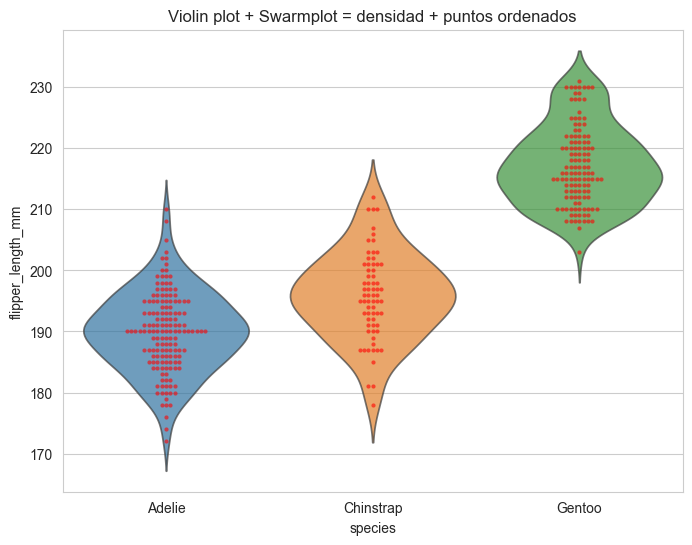

In [ ]:
## Violinplot + Swarmplot (puntos ordenados) ##
# swarmplot es similar a stripplot PERO ordena los puntos para evitar solapamientos,
# mostrando la densidad de forma más clara sin necesidad de jitter.
# Pero si nos muchos puntos, puede saturar el gráfico, por eso a veces es mejor usar stripplot con jitter.

plt.figure(figsize=(8, 6))

# Violin plot
sns.violinplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    inner=None,  # ← no mostrar el boxplot interno para no saturarar
    palette=custom_palette_species,
    alpha=0.7
)

# Swarmplot sobre el violin (puntos ordenados)
sns.swarmplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    color='red',  # ← un solo color para que no compita
    alpha=0.6,
    size=3
)

plt.title('Violin plot + Swarmplot = densidad + puntos ordenados')
plt.show()

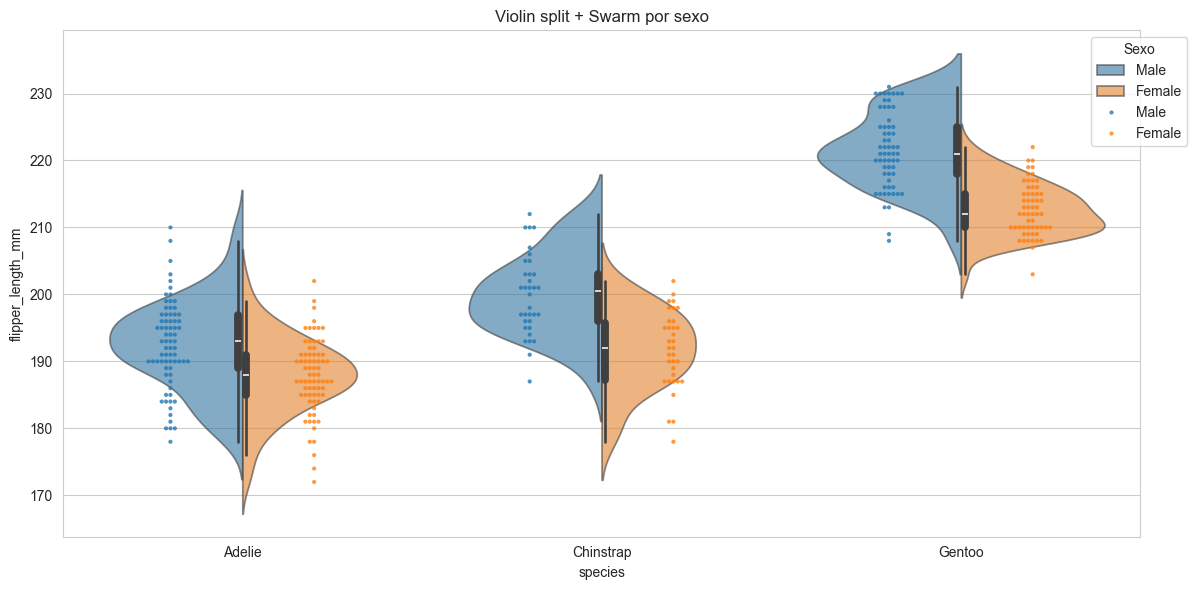

In [96]:
plt.figure(figsize=(12, 6))

# Violin plot con split por sexo
sns.violinplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    hue='sex',
    split=True,
    palette={'Male': '#1f77b4', 'Female': '#ff7f0e'},
    alpha=0.6
)

# Swarmplot con color por sexo
sns.swarmplot(
    data=df,
    x='species',
    y='flipper_length_mm',
    hue='sex',
    palette={'Male': '#1f77b4', 'Female': '#ff7f0e'},
    dodge=True,  # ← separa machos y hembras
    alpha=0.8,
    size=3
)

plt.title('Violin split + Swarm por sexo')
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Pero puede ser mejor un grafico tipo scatterplot que está diseñado para mostrar la relación entre DOS variables numéricas, mientras que un boxplot o violin plot se enfoca en mostrar la distribución de UNA variable numérica dentro de categorías.

Ahora bien:
regplot() → puntos + línea, NO soporta hue (es para una sola categoría)
scatterplot() → solo puntos, NO tiene line_kws
lmplot() → puntos + línea + soporta hue (es la más completa)

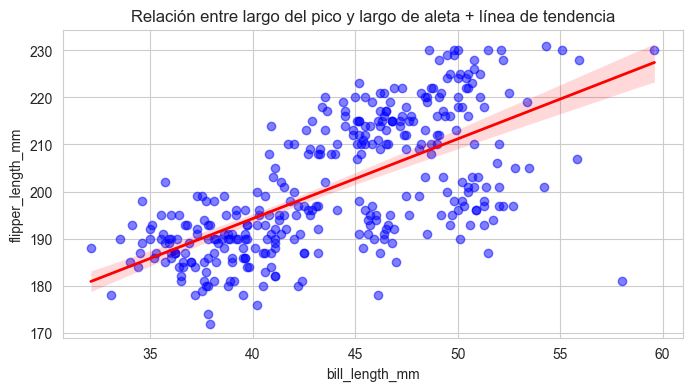

In [32]:
plt.figure(figsize=(8, 4))
sns.regplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    scatter_kws={'alpha': 0.5, 'color': 'blue'},
    line_kws={'color': 'red', 'linewidth': 2}
)
plt.title('Relación entre largo del pico y largo de aleta + línea de tendencia')
plt.show()

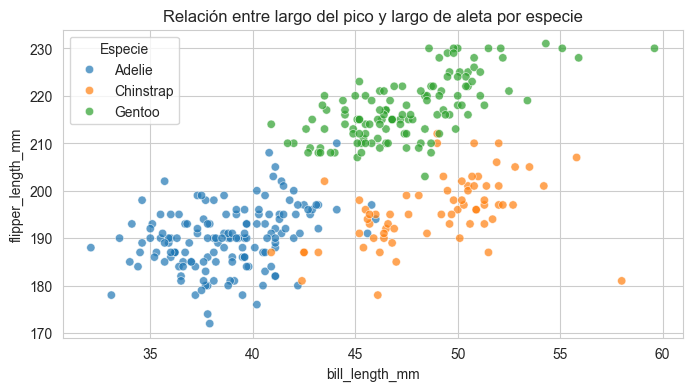

In [35]:
plt.figure(figsize=(8, 4))
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    alpha=0.7
)
plt.title('Relación entre largo del pico y largo de aleta por especie')
plt.legend(title='Especie')
plt.show()

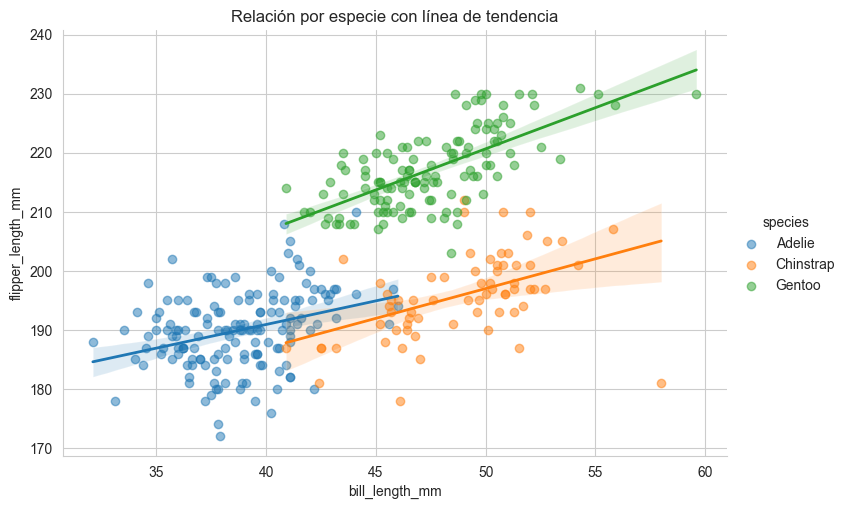

In [ ]:
#plt.figure(figsize=(8, 4))
sns.lmplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    #palette=custom_palette_species, no funciona con lmplot, solo con regplot 
        # se podria para una lista de colores personalizada // custom_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    # Opciones de la línea de tendencia
    #ci=95,  # intervalo de confianza para la línea de tendencia
    scatter_kws={'alpha': 0.5},
    line_kws={'linewidth': 2},
    # Dimensiones del gráfico
    height=5,
    aspect=1.5
)
plt.title('Relación por especie con línea de tendencia')
plt.show()



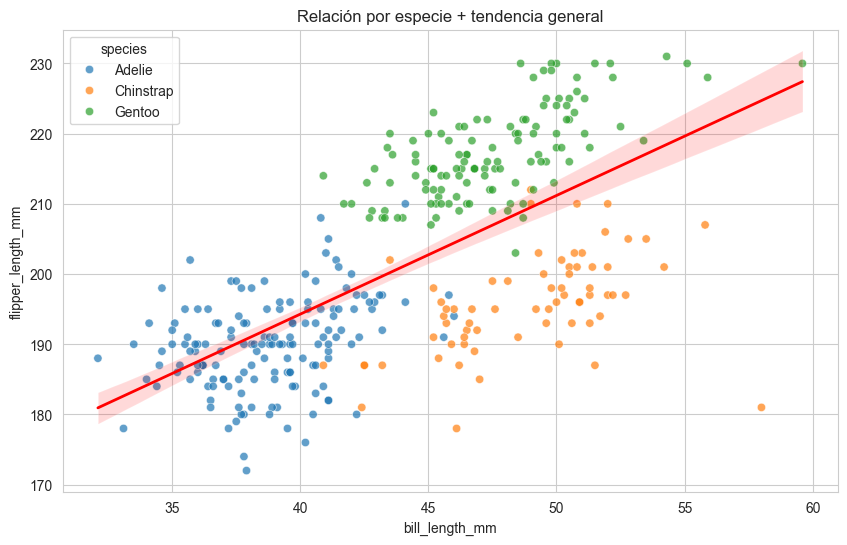

In [ ]:
### Combinar scatterplot + regplot para mostrar puntos por especie + tendencia general ###

plt.figure(figsize=(10, 6))

# Primero el scatterplot con colores por especie
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    alpha=0.7
)

# Luego añadir una línea de tendencia general (sin separar por especie)
sns.regplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    scatter=False,  # No dibujar puntos (ya los tenemos)
    color='red',
    line_kws={'linewidth': 2}
)

plt.title('Relación por especie + tendencia general')
plt.show()

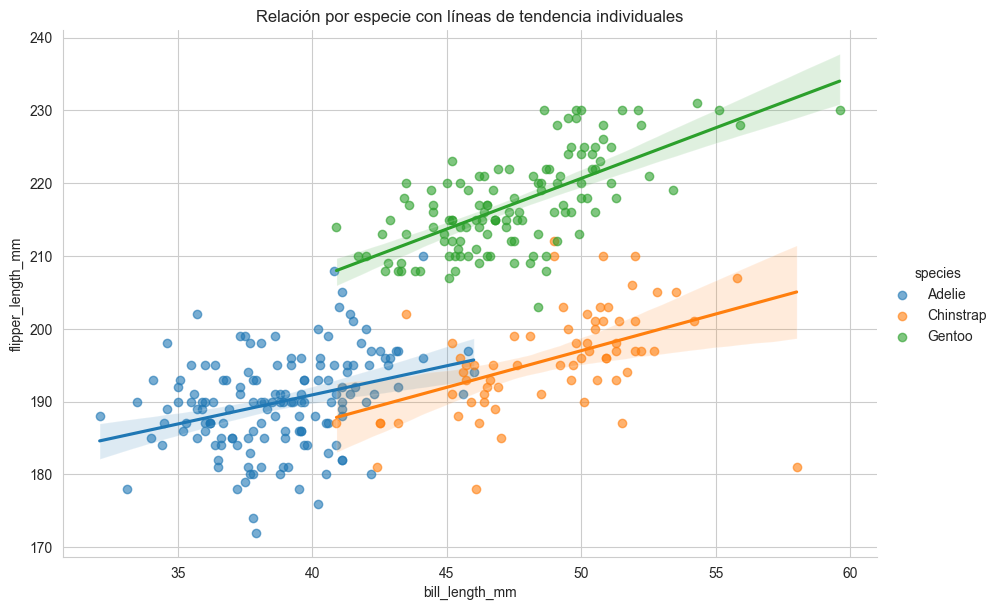

In [31]:
# Usar lmplot que hace todo de una vez
sns.lmplot(
    data=df,
    x='bill_length_mm',
    y='flipper_length_mm',
    hue='species',
    ci=95,  # intervalo de confianza
    scatter_kws={'alpha': 0.6},
    height=6,
    aspect=1.5
)
plt.title('Relación por especie con líneas de tendencia individuales')
plt.show()